In [34]:
import logging
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
sns.set_theme()
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s', 
                    stream=sys.stdout,
                    force=True)

In [ ]:
df=pd.read_csv("Mental_Health_Lifestyle_Dataset.csv") 
df

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Japan,57,Female,Moderate,Balanced,7.0,High,Depression,29,4.4,9.7,5.9
2996,Australia,27,Male,Low,Junk Food,7.1,Low,NaN,47,7.4,6.3,9.9
2997,Australia,42,Male,Moderate,Balanced,6.0,High,Depression,23,3.9,5.2,4.1
2998,Australia,25,Male,High,Keto,5.7,Low,Anxiety,51,4.3,5.9,4.1


Is there a significant association between stress level (ordinal) and average sleep hours?

In [35]:
df[['Stress Level','Sleep Hours']] #To see the data

,Stress Level,Sleep Hours
0,Low,6.3
1,Low,4.9
2,High,7.2
3,Low,7.2
4,Low,7.3
...,...,...
2995,High,7.0
2996,Low,7.1
2997,High,6.0
2998,Low,5.7


Create sleep hours per stress level plot

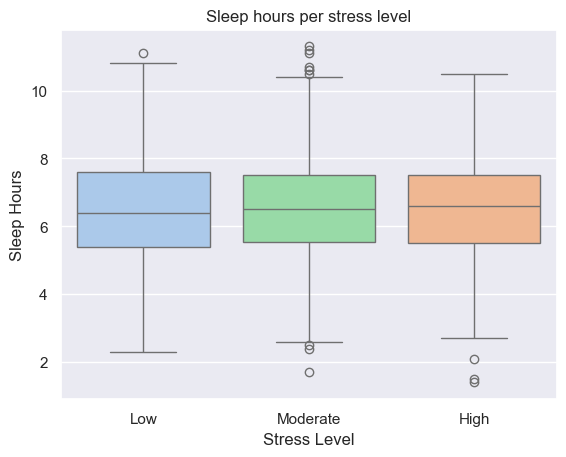

In [ ]:
cor_order=["Low","Moderate","High"] # control the order of stress levels in the plot
sns.boxplot(x=df['Stress Level'], y=df['Sleep Hours'],order=cor_order, hue=df["Stress Level"],palette='pastel' )
plt.title('Sleep hours per stress level')
plt.show()

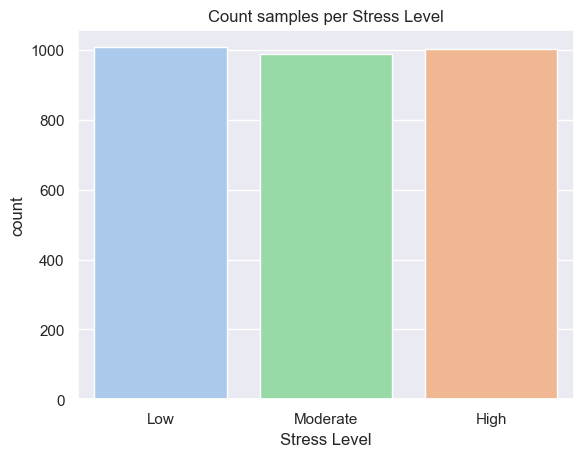

In [37]:
#Create a plot count samples per stress level
# To understed if the number of outliers in moderate sleep hours is due to the amount of pepole in this category.
sns.countplot(df, x="Stress Level",hue='Stress Level', order=cor_order, palette='pastel')
plt.title('Count samples per Stress Level')
plt.show()

Find the outliers

In [38]:
# To detect the outliers I used the The Tukey’s method, because the boxplot plot ues the same method.
Q1 = df['Sleep Hours'].quantile(0.25) # The lower percentile of the data
Q3 = df['Sleep Hours'].quantile(0.75) # The upper percentile of the data
IQR = Q3 - Q1 # finding the Interquartile Range
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Sleep Hours'] < lower) | (df['Sleep Hours'] > upper)]
outliers_stress=outliers.groupby('Stress Level').size() #finding the amount of outliers for each stress level
logging.info("Outliers per stress level:")
logging.info("\n%s", outliers_stress) #print the amount of outliers 
df_clean = df[(df['Sleep Hours'] >= lower) &(df['Sleep Hours'] <= upper)] #crete a new column without the outliers


2026-01-03 15:25:26,378 - INFO - Outliers per stress level:
2026-01-03 15:25:26,380 - INFO - 
Stress Level
High        3
Low         5
Moderate    8
dtype: int64


Spearman rank-order correlation

In [43]:
corr, p_value = spearmanr(df_clean['Sleep Hours'],df_clean['Stress Level'])
if p_value<0.05:
  logging.info(f"p-value is significant: {p_value}") 
else:
    logging.info(f"p-value isn't significant: {p_value}") 
logging.info(f"Spearman correlation: {corr}")  
  

2026-01-03 15:38:12,623 - INFO - p-value isn't significant: 0.4512987241271643
2026-01-03 15:38:12,626 - INFO - Spearman correlation: -0.013794374215344327


No statistically significant monotonic relationship was found between sleep hours and stress level, as indicated by Spearman’s rank correlation (ρ = −0.014).

Create heat map of correlation

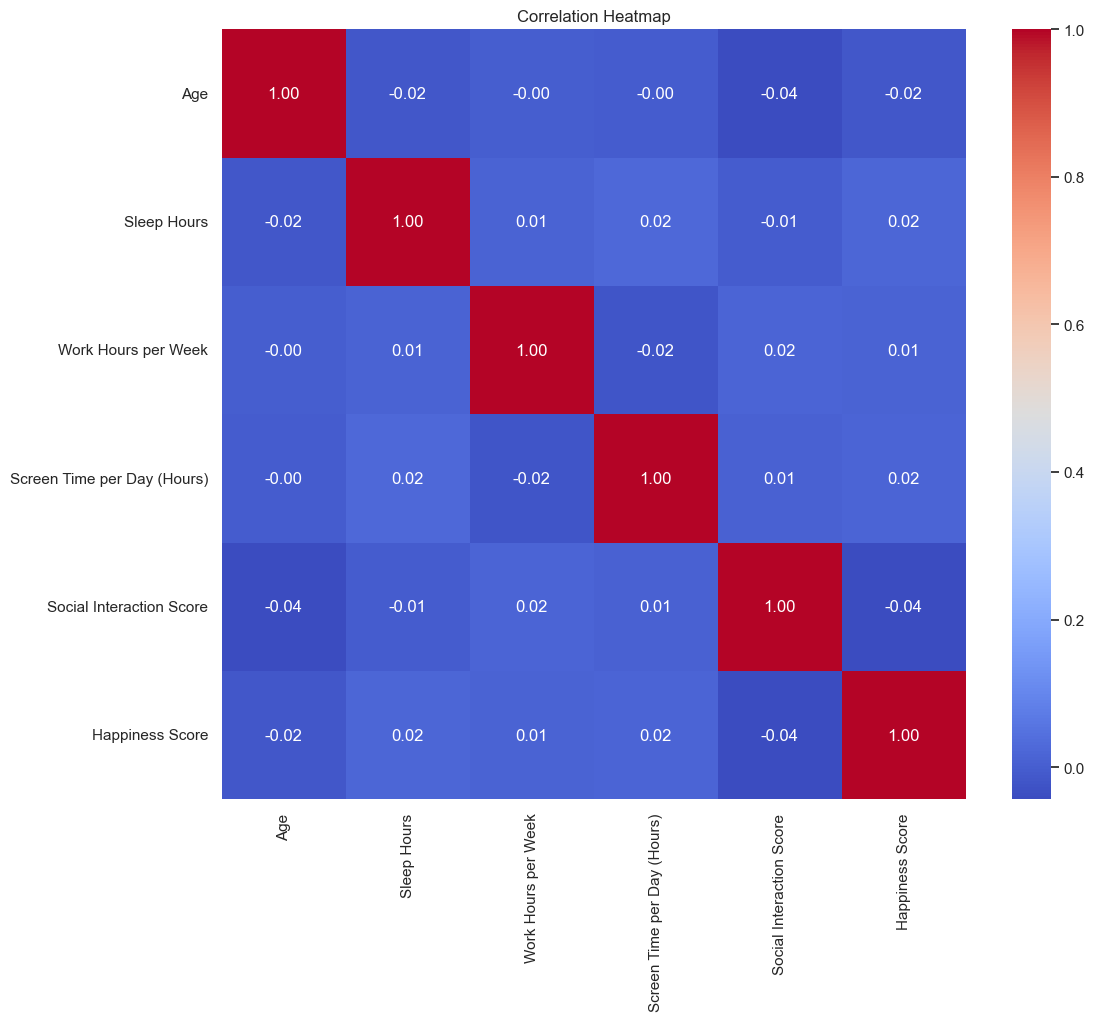

In [ ]:
numeric_df = df.select_dtypes(include=['number']) # including only the numeric category
corr_matrix = numeric_df.corr() #create matrix of pearson correlation
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()